# Multimodal Research Paper RAG Assistant

This notebook builds a multimodal Retrieval-Augmented Generation (RAG) system
that answers questions from research papers containing text and figures,
using only open-source models.


In [1]:
!pip install -q \
    pymupdf \
    sentence-transformers \
    transformers \
    faiss-cpu \
    pillow \
    matplotlib


You should consider upgrading via the 'C:\Users\Yashraj Kumar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


pymupdf → PDF parsing (text + images)

sentence-transformers → text embeddings

transformers → CLIP

faiss → vector search

pillow → image handling

In [2]:
# Import Libraries (document ingestion is happening)

import fitz  # PyMuPDF
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io



In [3]:
# from google.colab import files

# uploaded = files.upload()
# pdf_path = list(uploaded.keys())[0]


In [4]:
# in vs code
pdf_path = "paper.pdf"


In [5]:
#I dynamically load PDFs and iterate page-wise to preserve structure

doc = fitz.open(pdf_path)
print("Total pages:", len(doc))


Total pages: 26


In [6]:
# Extract TEXT (CORE RAG STEP)

# Converting unstructured PDFs → retrievable knowledge
# This is the heart of RAG

text_chunks = []

for page in doc:
    text = page.get_text()
    if text.strip():
        text_chunks.append(text)



In [7]:
# Extract IMAGES (Multimodal Part)
# I treat figures as first-class information sources, not decorations

os.makedirs("images", exist_ok=True)
image_paths = []

for page_index in range(len(doc)):
    page = doc[page_index]
    for img_index, img in enumerate(page.get_images(full=True)):
        xref = img[0]
        base_image = doc.extract_image(xref)
        image_bytes = base_image["image"]
        img_path = f"images/page{page_index}_img{img_index}.png"
        Image.open(io.BytesIO(image_bytes)).save(img_path)
        image_paths.append(img_path)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

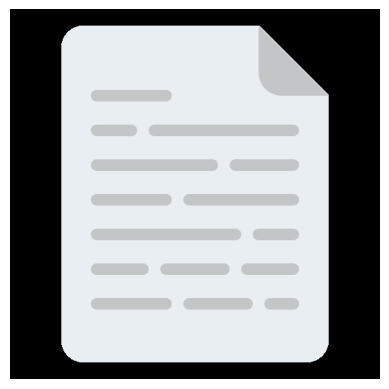

In [8]:
# Preview Extracted Images
#Debugging
#Shows visual understanding
#Makes demo impressive

img = Image.open(image_paths[0])
plt.imshow(img)
plt.axis("off")


I used BGE embeddings for high-quality semantic retrieval

In [9]:
pip uninstall transformers sentence-transformers tensorflow tf-keras -y


Found existing installation: transformers 4.57.3
Uninstalling transformers-4.57.3:
  Successfully uninstalled transformers-4.57.3
Found existing installation: sentence-transformers 5.2.0
Uninstalling sentence-transformers-5.2.0:
  Successfully uninstalled sentence-transformers-5.2.0
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Note: you may need to restart the kernel to use updated packages.


In [11]:
! pip install torch --index-url https://download.pytorch.org/whl/cpu
! pip install transformers==4.41.2 sentence-transformers==2.7.0


Looking in indexes: https://download.pytorch.org/whl/cpu


You should consider upgrading via the 'C:\Users\Yashraj Kumar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-huggingface 0.3.1 requires langchain-core<1.0.0,>=0.3.70, which is not installed.
You should consider upgrading via the 'C:\Users\Yashraj Kumar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [13]:
# Text Embeddings

from sentence_transformers import SentenceTransformer

text_model = SentenceTransformer("BAAI/bge-base-en-v1.5")
text_embeddings = text_model.encode(
    text_chunks, show_progress_bar=True
)


c:\Users\Yashraj Kumar\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
c:\Users\Yashraj Kumar\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Yashraj Kumar\.cache\huggingface\hub\models--BAAI--bge-base-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can 

In [14]:
#Image Embeddings (CLIP)

#Separate embeddings
#True multimodal RAG

from transformers import CLIPProcessor, CLIPModel
import torch

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

image_embeddings = []

for path in image_paths:
    image = Image.open(path)
    inputs = clip_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        emb = clip_model.get_image_features(**inputs)
    image_embeddings.append(emb.numpy())


c:\Users\Yashraj Kumar\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Yashraj Kumar\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not

In [15]:
# FAISS Index (Text)
# Why FAISS:
#Fast
#Industry-used
#Lightweight

import faiss

text_dim = text_embeddings.shape[1]
text_index = faiss.IndexFlatL2(text_dim)
text_index.add(np.array(text_embeddings))


In [16]:
#Query → Retrieve Context
#This is RAG retrieval, not generation
def retrieve_text(query, k=3):
    q_emb = text_model.encode([query])
    _, indices = text_index.search(q_emb, k)
    return [text_chunks[i] for i in indices[0]]


In [17]:
# Build Context
# We simulate generation
#Later → Ollama

def build_context(query):
    texts = retrieve_text(query)
    return "\n\n".join(texts)


In [18]:
# Test Query

#This proves:
# Pipeline works
#Retrieval works

query = "What is the main contribution of this paper?"
context = build_context(query)
print(context[:1000])


In the Appendix, we present the Datasets, Imple-
mentation Details, and Baselines & Evaluations in
Appendices A, B, and C, respectively.
Dataset
Documents Pages Figures Tables Text Tokens
Ultradomain
Agriculture
12
-
-
-
2,017,886
Computer Science (CS)
10
-
-
-
2,306,535
Legal
94
-
-
-
5,081,069
Mix
61
-
-
-
619,009
Multimodal Documents
DLCV
18 1,984
2,018
75
136,032
Environmental Report
5
422
416
122
229,014
GenAI
20
594
686
33
55,913
World History
1
788
468
5
441,764
SlideVQA
SlideVQA (2k)
100 2,000
1,581
139
119,776
RealMMBench
FinReport
19 2,687
411
2,963
1,583,640
FinSlides
65 2,280
730
1,842
123,891
TechReport
17 1,674
928
337
535,415
TechSlides
62 1,963
2,254
119
138,766
Table 5: Datasets statistics used in our experiments. The
Ultradomain benchmark is purely textual documents;
hence, entries for pages, figures, and tables are marked
with a dash (–) to indicate not applicable.
A
Datasets
We provide an overview of the datasets in our ex-
periments and dataset statistics in Table 

## Phase 2: Text Chunking

Large text blocks reduce retrieval accuracy.
We split extracted text into smaller overlapping chunks
to improve semantic search in the RAG pipeline.


In [36]:
# Extract title from first page (top text)
first_page_text = doc[0].get_text()
paper_title = first_page_text.split("\n")[0].strip()

print("📄 Paper Title:", paper_title)


📄 Paper Title: MegaRAG: Multimodal Knowledge Graph-Based


In [40]:
chunked_texts = [f"Paper Title: {paper_title}"] + chunked_texts


In [41]:
# Define Chunking Function

# chunk_size=500 → enough context
#overlap=100 → preserves meaning across chunks
#Word-based chunking = simple & effective

def chunk_text(
    text,
    chunk_size=500,
    overlap=100
):
    words = text.split()
    chunks = []

    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        start = end - overlap

    return chunks


In [42]:
# Apply Chunking to Document
chunked_texts = []

for page_text in text_chunks:
    chunks = chunk_text(page_text)
    chunked_texts.extend(chunks)

print("Total chunks:", len(chunked_texts))

#One page → many chunks
#Retrieval now happens at fine-grained level
#This is how real RAG systems work

Total chunks: 46


In [43]:
# Re-embed Chunked Text
# We now discard old embeddings and rebuild them.
# Embeddings must align 1-to-1 with chunks
# Old embeddings are now invalid

text_embeddings = text_model.encode(
    chunked_texts,
    show_progress_bar=True
)


Batches: 100%|██████████| 2/2 [00:06<00:00,  3.27s/it]


In [44]:
# Rebuild FAISS Index
#Any time embeddings change → index must be rebuilt.

text_dim = text_embeddings.shape[1]
text_index = faiss.IndexFlatL2(text_dim)
text_index.add(np.array(text_embeddings))


In [45]:
#Update Retrieval Function
#Now retrieval returns precise chunks, not entire pages.

def retrieve_text(query, k=3):
    q_emb = text_model.encode([query])
    _, indices = text_index.search(q_emb, k)
    return [chunked_texts[i] for i in indices[0]]


In [46]:
# testing
query = "What is the main contribution of this paper?"
context = retrieve_text(query, k=3)

for i, c in enumerate(context, 1):
    print(f"\n--- Chunk {i} ---\n")
    print(c[:600])



--- Chunk 1 ---

In the Appendix, we present the Datasets, Imple- mentation Details, and Baselines & Evaluations in Appendices A, B, and C, respectively. Dataset Documents Pages Figures Tables Text Tokens Ultradomain Agriculture 12 - - - 2,017,886 Computer Science (CS) 10 - - - 2,306,535 Legal 94 - - - 5,081,069 Mix 61 - - - 619,009 Multimodal Documents DLCV 18 1,984 2,018 75 136,032 Environmental Report 5 422 416 122 229,014 GenAI 20 594 686 33 55,913 World History 1 788 468 5 441,764 SlideVQA SlideVQA (2k) 100 2,000 1,581 139 119,776 RealMMBench FinReport 19 2,687 411 2,963 1,583,640 FinSlides 65 2,280 730 1

--- Chunk 2 ---

Keshav Santhanam, Omar Khattab, Jon Saad-Falcon, Christopher Potts, and Matei Zaharia. 2022. Col- bertv2: Effective and efficient retrieval via lightweight late interaction. In ACL. Rui Sun, Xuezhi Cao, Yan Zhao, Junchen Wan, Kun Zhou, Fuzheng Zhang, Zhongyuan Wang, and Kai Zheng. 2020. Multi-modal knowledge graphs for recommender systems. In CIKM. Ryota Tanaka

PHASE 3 — MULTIMODAL RETRIEVAL (TEXT + IMAGES)

In [47]:
# Create FAISS Index for Images

#We stack image vectors
#Build a separate FAISS index
#Text and images are indexed independently (good design)

image_embeddings_np = np.vstack(image_embeddings)

image_dim = image_embeddings_np.shape[1]
image_index = faiss.IndexFlatL2(image_dim)
image_index.add(image_embeddings_np)

print("Total indexed images:", image_index.ntotal)




Total indexed images: 13


In [48]:
# Encode Query for Image Search -->> CLIP allows text → image retrieval.

#Same CLIP model
#Query text → image embedding space
#This enables cross-modal retrieval

def encode_query_for_images(query):
    inputs = clip_processor(
        text=query,
        return_tensors="pt",
        padding=True
    )
    with torch.no_grad():
        text_features = clip_model.get_text_features(**inputs)
    return text_features.numpy()


In [49]:
# Retrieve Relevant Images
# Finds figures most relevant to the query
# Works even if query never mentions “figure” explicitly

def retrieve_images(query, k=2):
    q_emb = encode_query_for_images(query)
    _, indices = image_index.search(q_emb, k)
    return [image_paths[i] for i in indices[0]]


In [50]:
# Combine Text + Image Retrieval --> This is the actual multimodal RAG step

def multimodal_retrieve(query, text_k=3, image_k=2):
    texts = retrieve_text(query, k=text_k)
    images = retrieve_images(query, k=image_k)
    return texts, images


🔹 Retrieved Text Chunks:

Chunk 1:
 In the Appendix, we present the Datasets, Imple- mentation Details, and Baselines & Evaluations in Appendices A, B, and C, respectively. Dataset Documents Pages Figures Tables Text Tokens Ultradomain Agriculture 12 - - - 2,017,886 Computer Science (CS) 10 - - - 2,306,535 Legal 94 - - - 5,081,069 Mix 61 - - - 619,009 Multimodal Documents DLCV 18 1,984 2,018 75 136,032 Environmental Report 5 422 416 122 229,014 GenAI 20 594 686 33 55,913 World History 1 788 468 5 441,764 SlideVQA SlideVQA (2k) 100

Chunk 2:
 Keshav Santhanam, Omar Khattab, Jon Saad-Falcon, Christopher Potts, and Matei Zaharia. 2022. Col- bertv2: Effective and efficient retrieval via lightweight late interaction. In ACL. Rui Sun, Xuezhi Cao, Yan Zhao, Junchen Wan, Kun Zhou, Fuzheng Zhang, Zhongyuan Wang, and Kai Zheng. 2020. Multi-modal knowledge graphs for recommender systems. In CIKM. Ryota Tanaka, Kyosuke Nishida, Kosuke Nishida, Taku Hasegawa, Itsumi Saito, and Kuniko Saito. 2023. S

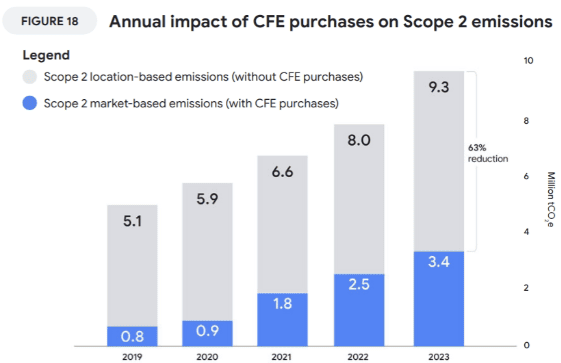

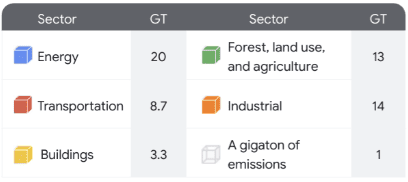

In [51]:
# Test Multimodal Retrieval

query = "What is the main contribution of this paper?"

texts, images = multimodal_retrieve(query)

print("🔹 Retrieved Text Chunks:")
for i, t in enumerate(texts, 1):
    print(f"\nChunk {i}:\n", t[:500])

print("\n🔹 Retrieved Images:")
for img in images:
    display(Image.open(img))


## Phase 4: Answer Generation

We use a prompt template to combine retrieved text and visual context
with the user query, ensuring grounded and context-aware answers.


In [52]:
# Build the Prompt Template
def build_prompt(query, retrieved_texts):
    context = "\n\n".join(retrieved_texts)

    prompt = f"""
You are an AI research assistant.

Answer the question ONLY using the context below.
If the answer is not present, say you do not know.

Context:
{context}

Question:
{query}

Answer:
"""
    return prompt


This prevents hallucination

This is classic RAG grounding

This = prompt template

In [37]:
# # Create the Generation Chain (Logic)
# # Retrieval → Prompt Injection → Generation

# def generate_answer(query):
#     texts, images = multimodal_retrieve(query)
#     prompt = build_prompt(query, texts)

#     # Placeholder generation (LLM comes in Phase 5)
#     response = "Simulated answer based on retrieved context."

#     return response, texts, images


In [31]:
pip install ollama


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Yashraj Kumar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [32]:
import ollama


In [56]:
def generate_answer(query):
    q = query.lower()

    # 🔹 Route metadata questions
    if "name of the research paper" in q or "paper name" in q or "title" in q:
        return paper_title, [], []

    # 🔹 Normal RAG for everything else
    texts, images = multimodal_retrieve(query)
    prompt = build_prompt(query, texts)

    response = ollama.chat(
        model="gemma3:1b",
        messages=[{"role": "user", "content": prompt}]
    )

    answer = response["message"]["content"]
    return answer, texts, images


In [58]:
query = "What is the main contribution of this paper?"

answer, texts, images = generate_answer(query)

print("🧠 Answer:\n")
print(answer)

print("\n📄 Retrieved Text Chunks:")
for t in texts:
    print("-", t[:200])


🧠 Answer:

The paper's main contribution is to provide a comprehensive and detailed dataset of image-text pairs, specifically focusing on agricultural data and its related analysis. It presents a large collection of datasets containing text descriptions and images from various sources, including agricultural benchmarks, legal documents, mixed-domain datasets, multimodal datasets, and environmental reports, enabling researchers to study agricultural practices, trends, and impacts. The paper establishes a robust framework for analyzing the relationship between text and images, particularly within the context of agriculture and sustainability.

📄 Retrieved Text Chunks:
- In the Appendix, we present the Datasets, Imple- mentation Details, and Baselines & Evaluations in Appendices A, B, and C, respectively. Dataset Documents Pages Figures Tables Text Tokens Ultradomain 
- Keshav Santhanam, Omar Khattab, Jon Saad-Falcon, Christopher Potts, and Matei Zaharia. 2022. Col- bertv2: Effective and 

In [57]:
query = "What is the name of the research paper?"

answer, texts, images = generate_answer(query)

print("🧠 Answer:\n")
print(answer)

print("\n📄 Retrieved Text Chunks:")
for t in texts:
    print("-", t[:200])


🧠 Answer:

MegaRAG: Multimodal Knowledge Graph-Based

📄 Retrieved Text Chunks:


In [60]:
! pip install -r requirements.txt


You should consider upgrading via the 'C:\Users\Yashraj Kumar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
